# ❤️ Heart Disease Prediction — XGBoost

**Dataset:** Heart Attack Dataset

**Goal:** Predict whether a patient has heart disease (Positive) or not (Negative) based on clinical measurements using Machine Learning.

## 📥 1. Load Dataset

The dataset is loaded using pandas to begin the analysis process.
Initial exploration is performed to understand:
- Dataset size (rows and columns)
- Feature names
- Overall structure

This helps in preparing the data for further preprocessing and modeling.

In [2]:
import pandas as pd

df = pd.read_csv('../data/Heart_Attack.csv')

print('Shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape: (1319, 9)

Column names:
['age', 'gender', 'impluse', 'pressurehight', 'pressurelow', 'glucose', 'kcm', 'troponin', 'class']

First 5 rows:


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


## 🧹 2. Data Cleaning & Preprocessing

In this step, we prepare the dataset for machine learning.

- Checked for missing values to identify any incomplete data
- Encoded the `gender` column: Male → 1, Female → 0
- Encoded the `class` column: positive → 1, negative → 0

These steps are necessary because machine learning models require all values to be numeric.

In [4]:
import pandas as pd

# Check missing values
print('Missing values:')
print(df.isnull().sum())

# Encode gender: M → 1, F → 0
if df['gender'].dtype == object:
    df['gender'] = df['gender'].str.upper().map({'M': 1, 'F': 0})

# Encode target: positive → 1, negative → 0
if df['class'].dtype == object:
    df['class'] = df['class'].map({'positive': 1, 'negative': 0})

print('\nDone! Sample data:')
df.head()

Missing values:
age              0
gender           0
impluse          0
pressurehight    0
pressurelow      0
glucose          0
kcm              0
troponin         0
class            0
dtype: int64

Done! Sample data:


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,0
1,21,1,94,98,46,296.0,6.75,1.060,1
2,55,1,64,160,77,270.0,1.99,0.003,0
3,64,1,70,120,55,270.0,13.87,0.122,1
4,55,1,64,112,65,300.0,1.08,0.003,0


## 📊 3. Exploratory Data Analysis (EDA)

In this step, we visualize the dataset to understand patterns and relationships between features and heart disease.

- Plotted the distribution of each clinical feature split by class (Positive vs Negative)
- This helps identify which features differ most between the two groups

These visualizations guide us in understanding which factors are most linked to heart disease.

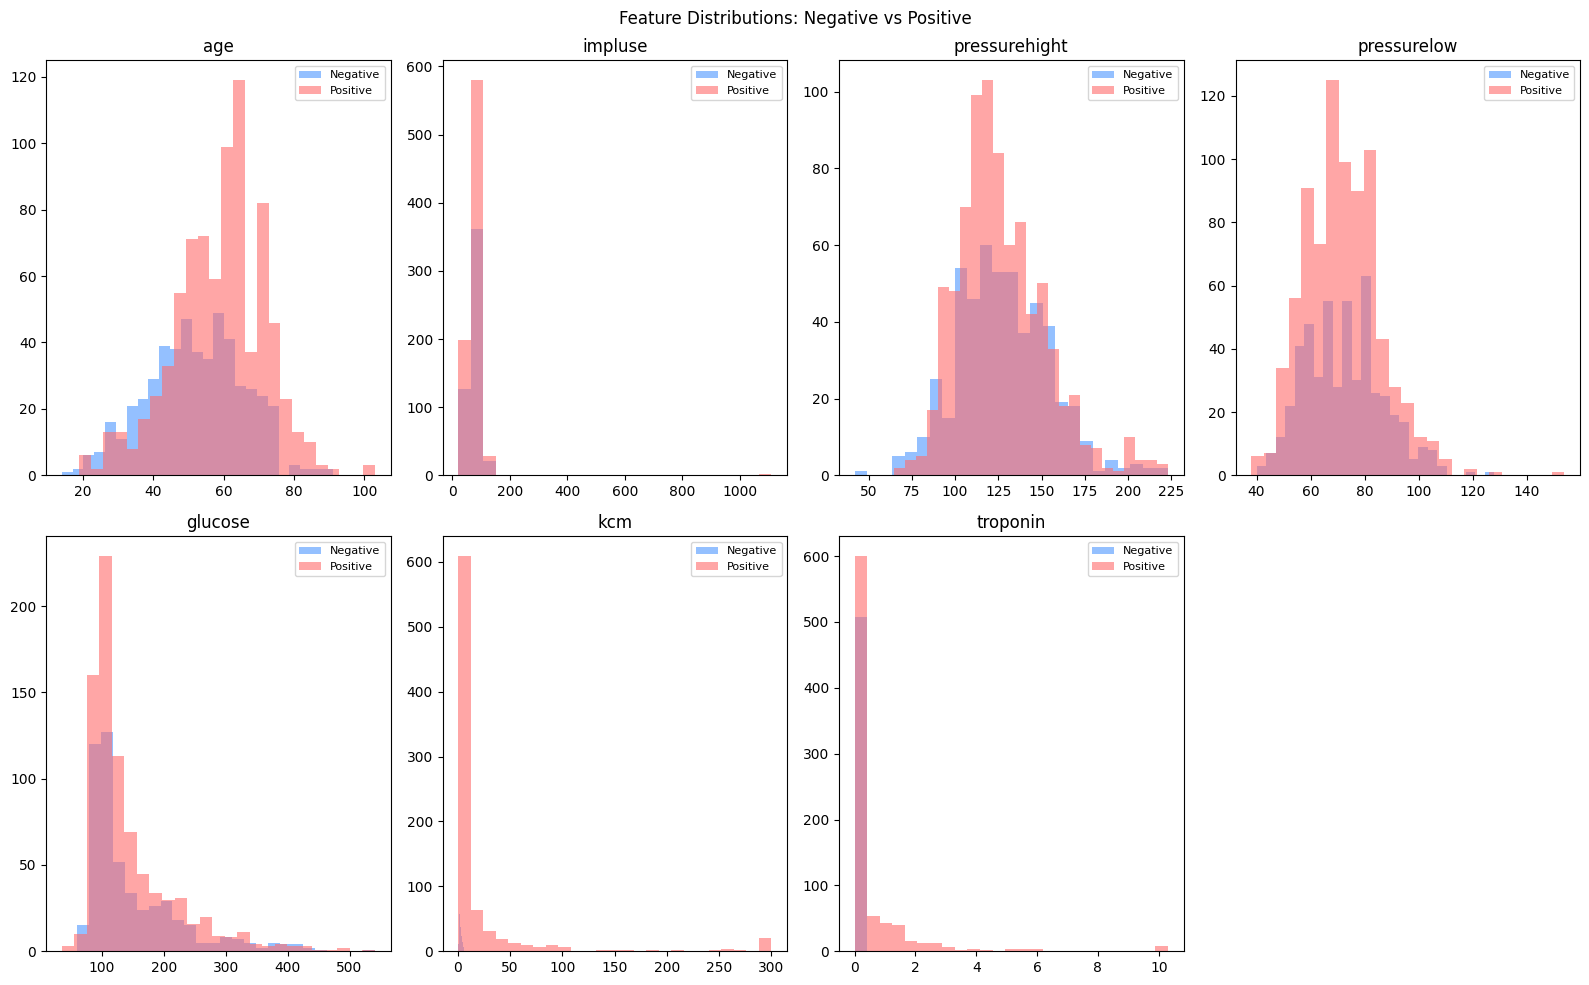

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

if df['gender'].dtype == object:
    df['gender'] = df['gender'].str.upper().map({'M': 1, 'F': 0})
if df['class'].dtype == object:
    df['class'] = df['class'].map({'positive': 1, 'negative': 0})

num_cols = ['age', 'impluse', 'pressurehight', 'pressurelow', 'glucose', 'kcm', 'troponin']

plt.figure(figsize=(16, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 4, i)
    plt.hist(df[df['class'] == 0][col], bins=25, alpha=0.6, color='#4D96FF', label='Negative')
    plt.hist(df[df['class'] == 1][col], bins=25, alpha=0.6, color='#FF6B6B', label='Positive')
    plt.title(col)
    plt.legend(fontsize=8)
plt.suptitle('Feature Distributions: Negative vs Positive')
plt.tight_layout()
plt.show()

## 🔗 4. Correlation Heatmap

In this step, we examine how features relate to each other and to the target.

- Computed the correlation matrix for all numeric columns
- Visualized it as a heatmap showing only the lower triangle

Values close to **+1** mean strong positive relationship. Values close to **-1** mean strong negative relationship. This helps spot which features are most predictive.

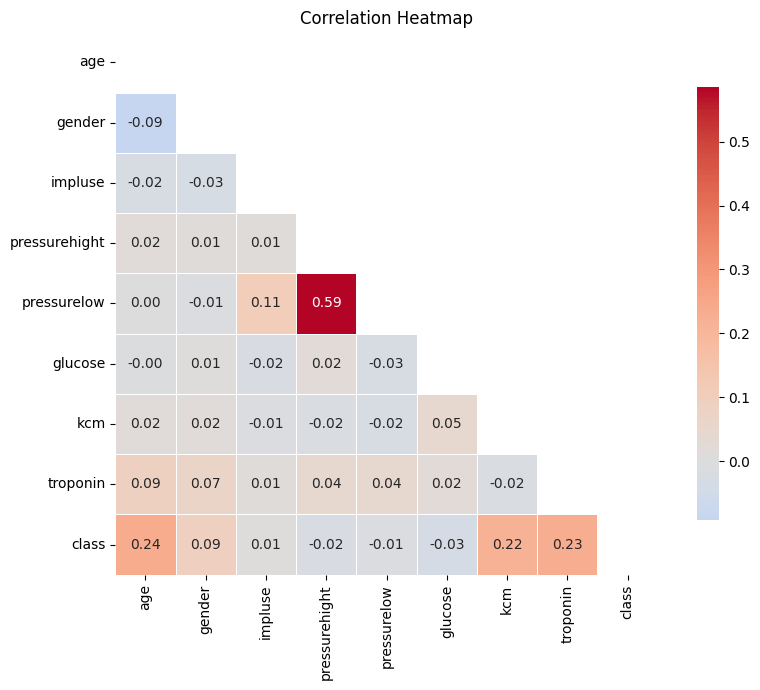

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if df['gender'].dtype == object:
    df['gender'] = df['gender'].str.upper().map({'M': 1, 'F': 0})
if df['class'].dtype == object:
    df['class'] = df['class'].map({'positive': 1, 'negative': 0})

plt.figure(figsize=(9, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

##  5. Split into Train & Test

In this step, we divide the dataset into training and testing sets.

- **80%** of data is used for training — the model learns from this
- **20%** of data is used for testing — the model has never seen this
- `stratify=y` ensures both splits have the same ratio of Positive and Negative cases

This prevents the model from being tested only on easy or hard cases.

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

if df['gender'].dtype == object:
    df['gender'] = df['gender'].str.upper().map({'M': 1, 'F': 0})
if df['class'].dtype == object:
    df['class'] = df['class'].map({'positive': 1, 'negative': 0})

X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Train:', X_train.shape[0], 'samples')
print('Test: ', X_test.shape[0], 'samples')
print('Class balance (train):', y_train.value_counts().to_dict())

Train: 1055 samples
Test:  264 samples
Class balance (train): {1: 648, 0: 407}


## 6. Model Training (XGBoost)

In this step, we train an XGBoost classifier to predict heart disease.

- Used `GridSearchCV` with 5-fold cross-validation to find the best settings
- Optimised for **Recall** — it is more important to catch real positive cases than to avoid false alarms
- The best model is selected automatically from the grid search results

XGBoost is a powerful gradient boosting algorithm that handles tabular data very well.

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier


if df['gender'].dtype == object:
    df['gender'] = df['gender'].str.upper().map({'M': 1, 'F': 0})
if df['class'].dtype == object:
    df['class'] = df['class'].map({'positive': 1, 'negative': 0})

X = df.drop(columns=['class'])
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0],
}

xgb = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42, n_jobs=-1)
grid = GridSearchCV(xgb, param_grid, cv=5, scoring='recall', n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)

model = grid.best_estimator_

print('Best parameters:')
for k, v in grid.best_params_.items():
    print(f'  {k}: {v}')
print('\nBest CV Recall:', round(grid.best_score_, 4))

Best parameters:
  learning_rate: 0.05
  max_depth: 4
  n_estimators: 100
  subsample: 1.0

Best CV Recall: 0.9892


## 7. Model Evaluation

In this step, the performance of the trained XGBoost model is evaluated using detailed metrics.

- A confusion matrix visualizes correct and incorrect predictions
- A classification report measures Precision, Recall, and F1-score per class

These metrics give a deeper understanding of model performance beyond simple accuracy, especially for medical predictions where missing a positive case is costly.

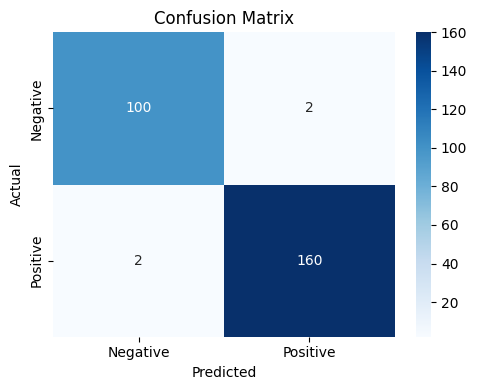

              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98       102
    Positive       0.99      0.99      0.99       162

    accuracy                           0.98       264
   macro avg       0.98      0.98      0.98       264
weighted avg       0.98      0.98      0.98       264



In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

if df['gender'].dtype == object:
    df['gender'] = df['gender'].str.upper().map({'M': 1, 'F': 0})
if df['class'].dtype == object:
    df['class'] = df['class'].map({'positive': 1, 'negative': 0})

X = df.drop(columns=['class'])
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0],
}
xgb = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42, n_jobs=-1)
grid = GridSearchCV(xgb, param_grid, cv=5, scoring='recall', n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)
model = grid.best_estimator_

y_pred = model.predict(X_test)

# Confusion Matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Detailed report
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

## 📉 8. ROC Curve & Feature Importance

In this step, we visualize how well the model separates the two classes and which features matter most.

- The ROC curve plots True Positive Rate vs False Positive Rate at different thresholds
- AUC (Area Under the Curve) summarizes overall model performance — closer to 1.0 is better
- The feature importance chart shows which clinical measurements the model relies on most

These charts help us interpret the model's decisions.

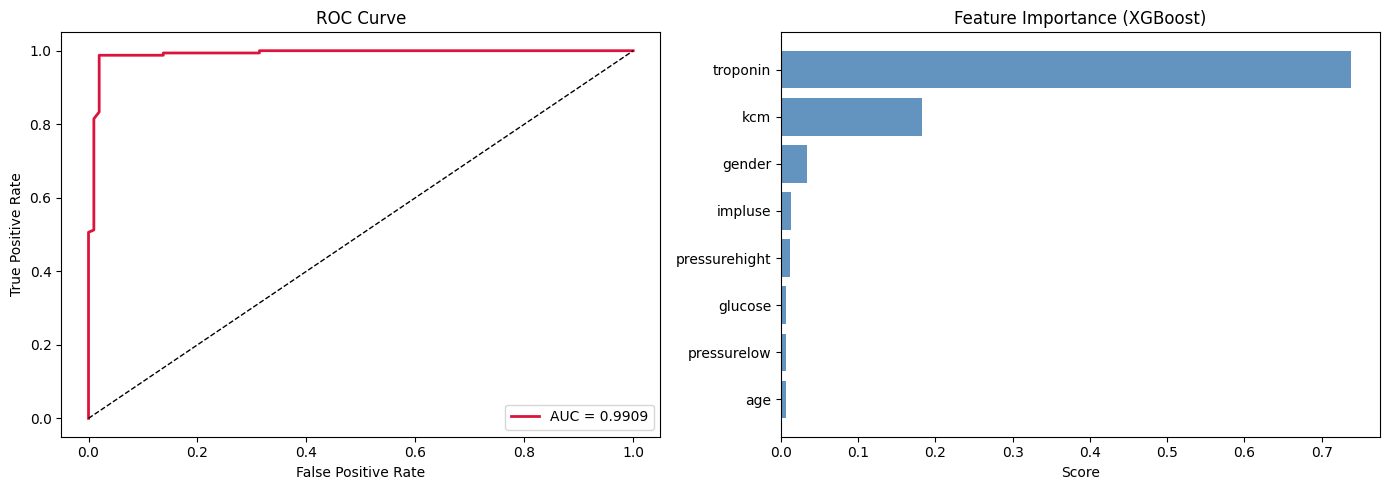

ROC-AUC: 0.9909


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

if df['gender'].dtype == object:
    df['gender'] = df['gender'].str.upper().map({'M': 1, 'F': 0})
if df['class'].dtype == object:
    df['class'] = df['class'].map({'positive': 1, 'negative': 0})

X = df.drop(columns=['class'])
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0],
}
xgb = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42, n_jobs=-1)
grid = GridSearchCV(xgb, param_grid, cv=5, scoring='recall', n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)
model = grid.best_estimator_

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(14, 5))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='crimson', lw=2, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

# Feature Importance
plt.subplot(1, 2, 2)
fi = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_}).sort_values('Importance', ascending=True)
plt.barh(fi['Feature'], fi['Importance'], color='steelblue', alpha=0.85)
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Score')

plt.tight_layout()
plt.show()

print('ROC-AUC:', round(auc_score, 4))

## 💾 9. Model Saving

In this step, the trained XGBoost model is saved to disk for future use.

- The model is saved using `joblib` so it can be reloaded without retraining
- This is useful for deploying the model in a real application

Once saved, the model can be loaded in any Python script to make predictions instantly.

In [16]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier

if df['gender'].dtype == object:
    df['gender'] = df['gender'].str.upper().map({'M': 1, 'F': 0})
if df['class'].dtype == object:
    df['class'] = df['class'].map({'positive': 1, 'negative': 0})

X = df.drop(columns=['class'])
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0],
}
xgb = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42, n_jobs=-1)
grid = GridSearchCV(xgb, param_grid, cv=5, scoring='recall', n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)
model = grid.best_estimator_

joblib.dump(model, 'heart_disease_xgb.pkl')
print('Model saved!')

Model saved!


## 🔮 10. Model Saving & Prediction

In this step, the saved model is loaded and used to make predictions on new patients.

- A new patient's clinical data is entered manually as input
- The model predicts whether the patient has heart disease or not
- Probability scores are shown alongside each prediction

This demonstrates how the trained model can be applied to real-world data.

| Column | Meaning |
|---|---|
| `age` | Age in years |
| `gender` | 1 = Male, 0 = Female |
| `impluse` | Heart rate (pulse) |
| `pressurehight` | Systolic blood pressure |
| `pressurelow` | Diastolic blood pressure |
| `glucose` | Blood glucose level |
| `kcm` | Creatine kinase-MB enzyme |
| `troponin` | Troponin level (heart damage marker) |

In [ ]:
# Preprocessing: Scaling and ColumnTransformer for numeric features
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_features = ['age', 'impluse', 'pressurehight', 'pressurelow', 'glucose', 'kcm', 'troponin']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features)
], remainder='passthrough')

Model loaded!

Patient Predictions:


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,result,prob_negative (%),prob_positive (%)
0,45,1,80,130,85,120,1.5,0.010,🟢 Negative,99.300003,0.700000
1,62,0,95,165,100,210,3.2,0.180,🔴 Positive,0.500000,99.500000
2,38,1,70,118,75,88,0.7,0.002,🟢 Negative,98.900002,1.100000
3,55,0,88,145,92,160,2.1,0.090,🔴 Positive,0.400000,99.599998
